# Comparación entre K-Nearest Neighbors (KNN) y Árboles de Decisión

Usaremos un dataset descargado de Kaggle con mas de 6 millones de datos:
- 0 = no es fraude
- 1 = es fraude


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns

## Leemos los datos

In [ ]:
# cargar datos de un csv
df = pd.read_csv("/content/onlinefraud.csv")
df


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
# ver datos nulos
df.isnull().sum()


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
#eiliminamos daotos nulos
df.dropna(inplace=True)

# Seleccionamos dos variables para la visualizacion K _ NN

División en entrenamiento y prueba

In [ ]:
#selecionamos los datos preditorios y a prdecir
features =["amount",	"oldbalanceOrg",	"newbalanceOrig",	"oldbalanceDest",	"newbalanceDest"]
X = df[features]
y = df['isFraud'] # objetivo
# dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# evaluacion del modelo K-NN utilizando metricas y matriz de confusiòn

In [ ]:
# entrenamos el modelo
knn = KNeighborsClassifier(n_neighbors=14, weights='distance')

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
# imprimimos metricas
print("Métricas KNN:")
print(classification_report(y_test, y_pred_knn))




Métricas KNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.86      0.65      0.74      2435

    accuracy                           1.00   1908786
   macro avg       0.93      0.83      0.87   1908786
weighted avg       1.00      1.00      1.00   1908786



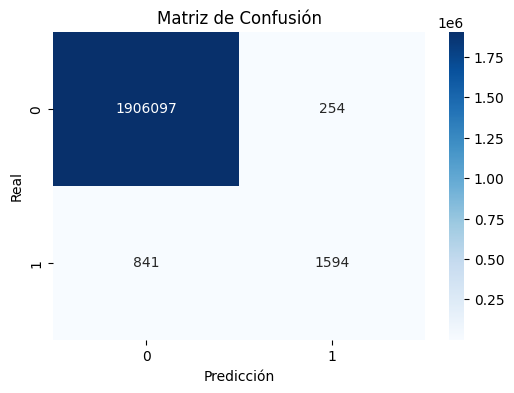

In [ ]:
# Usamos la matriz de confusion
knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(knn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

## Árbol de Decisión



In [ ]:
tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.85      0.39      0.53      2435

    accuracy                           1.00   1908786
   macro avg       0.92      0.69      0.77   1908786
weighted avg       1.00      1.00      1.00   1908786



Visualización del Árbol de Decisión

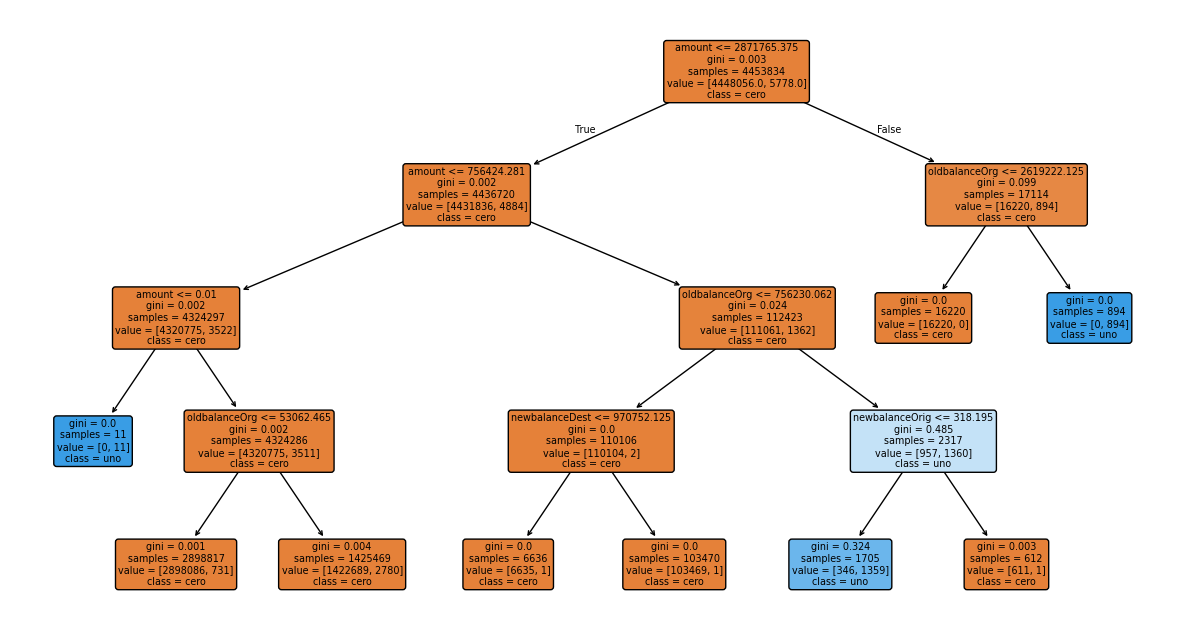

In [ ]:
plt.figure(figsize=(15,8))
plot_tree(tree, feature_names=X.columns, class_names=["cero", "uno"], filled=True, rounded=True)
plt.show()

Accuracy KNN: 0.9994263369492442
Accuracy Árbol: 0.9991319089725093


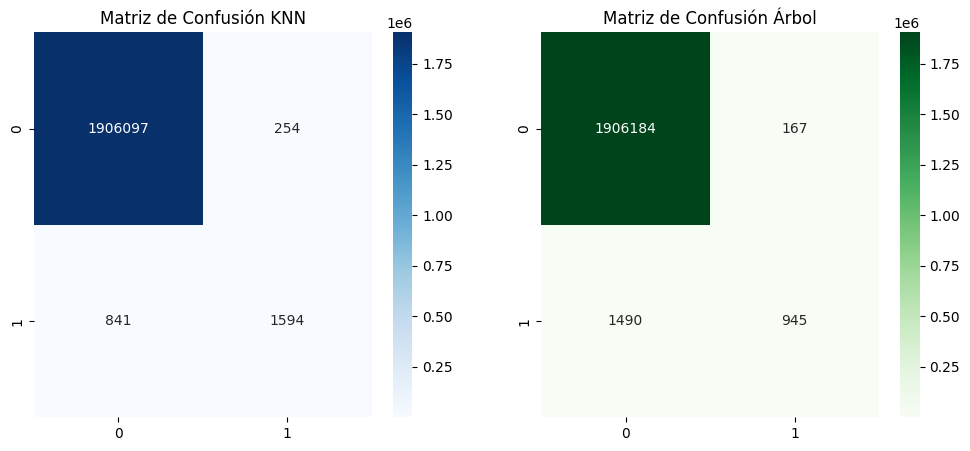

In [ ]:
print("Accuracy KNN:", accuracy_score(y_test, y_pred_knn))
print("Accuracy Árbol:", accuracy_score(y_test, y_pred_tree))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión KNN")

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Matriz de Confusión Árbol")
plt.show()